In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
def load_path(base_path, part):
    rows = []

    for split in os.listdir(base_path):
        split_path = os.path.join(base_path, split)
        if not os.path.isdir(split_path):
            continue

        for body in os.listdir(split_path):
            if body != part:
                continue

            body_path = os.path.join(split_path, body)

            for patient_id in os.listdir(body_path):
                patient_path = os.path.join(body_path, patient_id)

                for lab in os.listdir(patient_path):
                    if lab.endswith("positive"):
                        label = 1
                    elif lab.endswith("negative"):
                        label = 0
                    else:
                        continue

                    lab_path = os.path.join(patient_path, lab)
                    for img in os.listdir(lab_path):
                        rows.append({
                            "filepath": os.path.join(lab_path, img),
                            "label": label,
                            "patient_id": patient_id
                        })

    return pd.DataFrame(rows)


In [3]:
BASE_DIR = os.getcwd()
DATASET_DIR = os.path.join(BASE_DIR, "Dataset")

PART = "Elbow"   # change to Hand / Shoulder
df = load_path(DATASET_DIR, PART)

gss = GroupShuffleSplit(test_size=0.1, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df["patient_id"]))

train_df = df.iloc[train_idx]
test_df  = df.iloc[test_idx]

# validation split
val_df = train_df.sample(frac=0.2, random_state=42)
train_df2 = train_df.drop(val_df.index)


In [4]:
IMG_SIZE = 224
BATCH_SIZE = 16

def decode_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.keras.applications.resnet50.preprocess_input(img)
    return img, label

def make_dataset(df, training=False):
    ds = tf.data.Dataset.from_tensor_slices((df.filepath.values, df.label.values))
    ds = ds.map(decode_image, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(2048)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df2, training=True)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)


In [5]:
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0,1]),
    y=train_df2["label"].values
)

class_weights = {0: weights[0], 1: weights[1]}
print(class_weights)


{0: 0.838076757222941, 1: 1.2394770408163265}


In [6]:
base_model = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # transfer learning

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.4)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [7]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stop],
    class_weight=class_weights
)

Epoch 1/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 346s 1s/step - accuracy: 0.6410 - loss: 0.6911 - val_accuracy: 0.7202 - val_loss: 0.5621
Epoch 2/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 646s 3s/step - accuracy: 0.6858 - loss: 0.5992 - val_accuracy: 0.7582 - val_loss: 0.5316
Epoch 3/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 318s 1s/step - accuracy: 0.7080 - loss: 0.5550 - val_accuracy: 0.7716 - val_loss: 0.5106
Epoch 4/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 345s 1s/step - accuracy: 0.7509 - loss: 0.5017 - val_accuracy: 0.7654 - val_loss: 0.5078
Epoch 5/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 233s 951ms/step - accuracy: 0.7654 - loss: 0.4815 - val_accuracy: 0.7870 - val_loss: 0.4931
Epoch 6/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 239s 974ms/step - accuracy: 0.7794 - loss: 0.4685 - val_accuracy: 0.7706 - val_loss: 0.4921
Epoch 7/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 249s 1s/step - accuracy: 0.7797 - loss: 0.4551 - val_accuracy: 0.7726 - val_loss: 0.5013
Epoch 8/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 266s 1s/step - accuracy: 0.7719 - loss: 0.4859 - va

In [8]:
loss, acc = model.evaluate(test_ds)
print(f"ResNet50 Test Accuracy: {acc*100:.2f}%")

34/34 ━━━━━━━━━━━━━━━━━━━━ 30s 881ms/step - accuracy: 0.7566 - loss: 0.5093
ResNet50 Test Accuracy: 78.96%


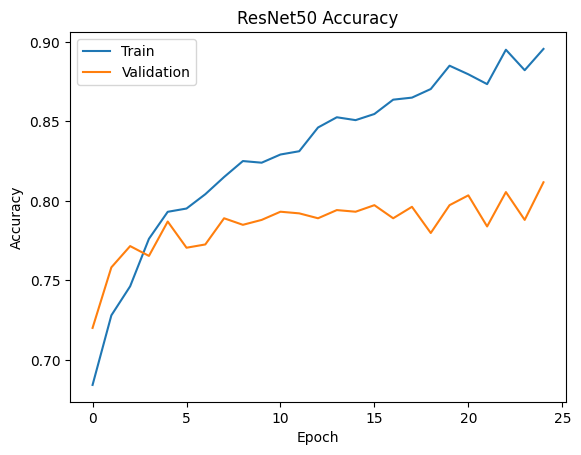

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('ResNet50 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

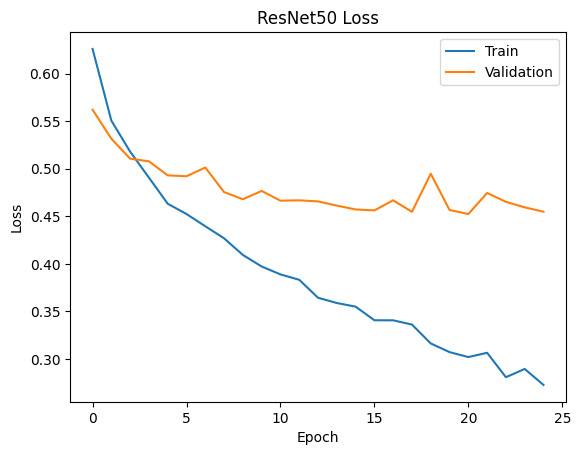

In [13]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('ResNet50 Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
y_pred_probs = model.predict(test_ds)
y_pred = (y_pred_probs > 0.5).astype(int).ravel()
y_true = test_df["label"].values

print(confusion_matrix(y_true, y_pred))
print(classification_report(
    y_true,
    y_pred,
    target_names=["Normal", "Fractured"]
))

34/34 ━━━━━━━━━━━━━━━━━━━━ 28s 810ms/step
[[244  37]
 [ 76 180]]
              precision    recall  f1-score   support

      Normal       0.76      0.87      0.81       281
   Fractured       0.83      0.70      0.76       256

    accuracy                           0.79       537
   macro avg       0.80      0.79      0.79       537
weighted avg       0.79      0.79      0.79       537



<Figure size 600x600 with 0 Axes>

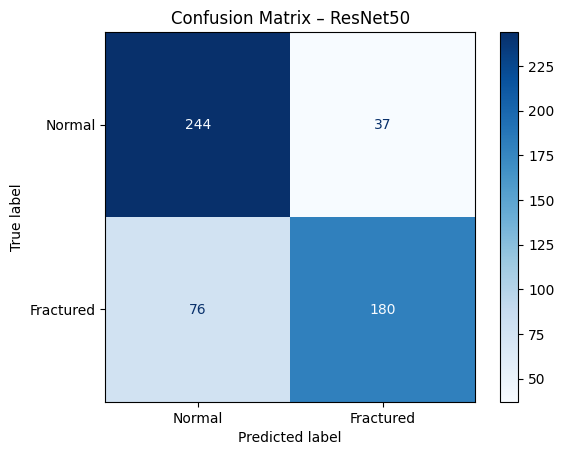

In [ ]:
class_names = ["Normal", "Fractured"]

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_true, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
plt.figure(figsize=(6, 6))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix – ResNet50")
plt.show()

In [26]:
model.save(os.path.join(os.getcwd(), "weights", "ResNet50_Elbow.keras"))
